## Regression Basics

- Dependent variable or response variables
- Independent variables
- Regression: Finding relationship, based on data
- For example a linear relationship:
    - $Y = \beta_0 + \beta_1 x_1 + ... + \beta_r x_r$


## Linear Regression

- In actuality to account for error:
    - $Y = \beta_0 + \beta_1 x_1 + ... + \beta_r x_r + e$
- Let $e$ be a RV with mean 0, then

$$E[Y|\mathbf{x}] = \beta_0 + \beta_1 x_1 + ... + \beta_r x_r$$

- *Linear regression equation*
- $\beta_i$ are *regression coefficients*

## Linear Regression

- If $r=1$: simple regression equation
- $r>1$ multiple regression equation


## What is an estimator

- Estimator: statistic to estimate unknown parameter
- Think of it as a formula that is an estimate of some parameter
   - Ex: $\mu$ or $\sigma$ of a normal distribution
   - Or: The probability of success in a coin toss, $p$
   - Estimator for $p = \sum_{i=1}^N x_i /N$

## Least squares estimators of parameters

- Consider: $Y = \alpha + \beta x$
- Let $A, B$ be estimators for the parameters
- Measure two variables, $Y_i, x_i$
- **Minimize** sum of squared differences:

$$SS = SS_R = \sum_{i=1}^n (Y_i - A - B x_i)^2$$

- $SS_R$ is the sum of squares of the *residuals*


## Normal equations

- Differentiate w.r.t. $A, B$ and set to zero

    - $\sum Y_i = nA + B \sum x_i$
    - $\sum x_i Y_i = A\sum x_i + B \sum x_i^2$

<br/>

- Let $\bar{Y} = \sum_{i=0}^n \frac{Y_i}{n}$;
- $\bar{x} = \sum_{i=0}^n \frac{x_i}{n}$


## Solution

- $B=\frac{\sum x_i Y_i - n\bar{x}\bar{Y}}{\sum x_i^2 - n \bar{x}^2}$
- $A = \bar{Y} - B\bar{x}$

- $S_{xx} = \sum_i (x_i - \bar{x})^2$
- $S_{YY} = \sum_i (Y_i - \bar{Y})^2$
- $S_{xY} = \sum_i (x_i - \bar{x})(Y_i - \bar{Y})$
- $B = \frac{S_{xY}}{S_{xx}}$
- An identity: $SS_R = \frac{S_{xx}S_{YY} - S_{xY}^2}{S_{xx}}$


## Coefficient of determination

- $S_{YY}$: variation in the set of values $Y_i$
- $SS_R$: variation in responses after considering inputs
- $S_{YY} - SS_R$: variation in response explained by the inputs
- Coefficient of determination: $R^2 = \frac{S_{YY} - SS_R}{S_{YY}} = 1 - \frac{SS_R}{S_{YY}}$
- $0 \leq R^2 \leq 1$
- Values near 1 indicate that the model explains the variation
- Note that Pearson's correlation: $|r| = \sqrt{R^2}$

## How do you assess the linear model

- Consider $\frac{Y_i - (A + B x_i)}{\sqrt{SS_R/(n-2)}}$
- Standardized residuals
- Should be a standard normal
- Plot standardized residuals vs. $x_i$
- The residuals should be between $\pm 2$
- No pattern should be seen in the plot
- See examples down below

## Some connections

- Minimizing $SS_R$ is same as MLE for parameters assuming a normal
  distribution!
- Already seen connection between Pearson's correlation and $R^2$
- Useful to recall ideas on how to plot/assess the linear model


## Transforming for linearity

- Can transform equation so it is linear
- Example: $W(t) = c e^{-a t}$
- Example: $1 - P(x) = c(1 -d)^x$
- Can apply a transformation to reduce this to a linear equation (Exercise!)
- Key point being the equation is linear in the coefficients

## Polynomial regression

- $Y = \beta_0 + \beta_1 x + \ldots + \beta_r x^r$
- Again minimize error
- Get a set of normal equations
    - Differentiate w.r.t. parameters and set to zero
- Solve a system of equations to find parameters
- See below for a quick way

## Multiple linear regression

- Need to solve matrices to find the normal equations
- Derive the general equations
- Define:

$$ Y =   \begin{bmatrix}
  Y_1 \\
  Y_2 \\
  \vdots\\
  Y_N \\
\end{bmatrix}
$$

$$
X = \begin{bmatrix}
  1 & x_{11} & x_{12} & \cdots & x_{1k} \\
  1 & x_{21} & x_{22} & \cdots & x_{2k} \\
  \vdots & \vdots & \vdots & & \vdots \\
  1 & x_{n1} & x_{n2} & \cdots & x_{nk} \\
\end{bmatrix}
$$

## Solution
- $Y = XB + e$
- $X^T X B = X^T Y$
- $B = (X^TX)^{-1} X^T Y$

## Now for some code!

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ipywidgets import interact

## Recap of earlier material

- Least square fit from scratch revisit numpy notebook

- $ t^2 = m \cdot l + c$

- Setup this in terms of a matrix equation
- $t^2 = A \cdot p$

$$
  \begin{bmatrix}
  T^2_1 \\
  T^2_2 \\
  \vdots\\
  T^2_N \\
\end{bmatrix}
= \begin{bmatrix}
  L_1 & 1 \\
  L_2 & 1 \\
  \vdots & \vdots\\
  L_N & 1 \\
\end{bmatrix} \cdot
\begin{bmatrix}
  m\\
  c\\
  \end{bmatrix}
$$


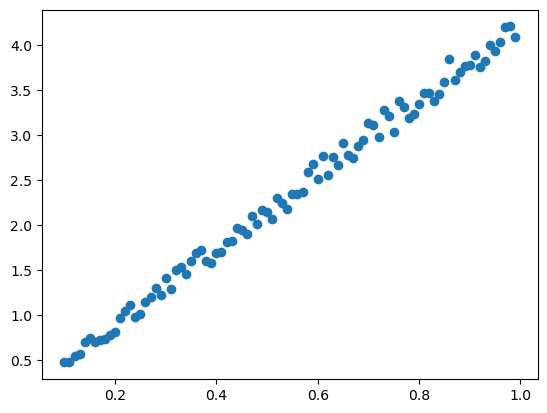

In [3]:
el, t = np.loadtxt('data/pendulum.txt', unpack=True)
tsq = t*t
plt.scatter(el, tsq);

In [ ]:
a = np.array([el, np.ones_like(el)]).T

In [ ]:
result = np.linalg.lstsq(a, tsq)
coef = result[0]
coef

In [ ]:
tp = coef[0]*el + coef[1]
plt.plot(el, tp, 'r', lw=3)
plt.scatter(el, tsq);

## What we did earlier above

- $y_i = b_0 + b_1 x_i$
- $S_{xx} = \sum_i (x_i - \bar{x})^2$
- $S_{yy} = \sum_i (y_i - \bar{y})^2$
- $S_{xy} = \sum_i (x_i - \bar{x})(y_i - \bar{y})$
- $b_1 = \frac{S_{xy}}{S_{xx}}$
- $b_0 = \bar{y} - b_1 \bar{x}$

In [ ]:
xb = np.mean(el)
yb = np.mean(tsq)
sxx = np.sum((el - xb)**2)
sxy = np.sum((el - xb)*(tsq - yb))
b1 = sxy/sxx
b0 = yb - b1*xb
print(b1, b0)
print("Earlier coefficients,", coef)

## A shorter way

- Use `np.polyfit`


In [ ]:
coef = np.polyfit(el, tsq, 1)  # Look at the docs.
coef

## Coefficient of determination

- $S_{YY} = \sum_i (Y_i - \bar{Y})^2$
- $SS_R = \sum_{i=1}^n (Y_i - A - B x_i)^2$
- $R^2 = \frac{S_{YY} - SS_R}{S_{YY}} = 1 - \frac{SS_R}{S_{YY}}$


In [ ]:
ssr = np.sum((tp - tsq)**2)
tbar = np.mean(tsq)
syy = np.sum((tsq - tbar)**2)
rsq = 1 - ssr/syy
ssr, syy, rsq

## Exploring this with some simple data

- Make some simple data

In [ ]:
n = 20
err = 0.2
x = np.linspace(0, 1, n)
y = 2*x + 0.25
yn = y + np.random.normal(loc=0, scale=err, size=n)

In [ ]:
def fit(x, y):
    return np.polyfit(x, y, 1)


def predict(coef, x):
    return coef[0]*x + coef[1]


def get_rsq(y, yp):
    ssr = np.sum((yp - y)**2)
    ybar = np.mean(y)
    syy = np.sum((y - ybar)**2)
    return 1.0 - ssr/syy

- A convenience

In [ ]:
def fit_predict(x, y):
    coef = fit(x, y)
    yp = predict(coef, x)
    r2 = get_rsq(y, yp)
    return yp, r2, coef

In [ ]:
def show(x, y, yp, rsq):
    plt.subplot(1, 2, 1)
    plt.plot(x, y, 'o')
    plt.plot(x, yp, 'r', linewidth=2, label=r'Fit $(R^2 = %.3f)$' % rsq)
    plt.legend(fontsize=12)
    plt.grid()
    sigma = np.sqrt(np.sum((y - yp)**2)/(len(y) - 2))
    std_res = (y - yp)/sigma
    plt.subplot(1, 2, 2)
    plt.plot(x, std_res, 'o')
    plt.ylim(-2, 2)
    plt.grid()

In [ ]:
def make_data(n, err=0.2):
    x = np.linspace(0, 1, n)
    y = 2*x + 0.25
    yn = y + np.random.normal(loc=0, scale=err, size=n)
    return x, yn

- An example

In [ ]:
x, yn = make_data(10)
yp, rsq, coef = fit_predict(x, yn)
print(rsq, coef)
show(x, yn, yp, rsq)

## Putting it together

In [ ]:
@interact(n=(5, 100), err=(0.0, 1.0))
def fit_noise(n=10, err=0.2):
    x, yn = make_data(n, err)
    yp, rsq, coef = fit_predict(x, yn)
    show(x, yn, yp, rsq)



## What if?

- Consider a quadratic or cubic curve or sine

In [ ]:
def make_data1(n=10, err=0.2):
    x = np.linspace(0, 3.0, n)
    y = x*x + x + 0.25
    yn = y + np.random.normal(loc=0, scale=err, size=n)
    return x, yn

In [ ]:
@interact(n=(5, 100), err=(0.0, 1.0))
def fit_noise(n=10, err=0.2):
    x, yn = make_data1(n, err)
    coef = fit(x, yn)
    yp = predict(coef, x)
    rsq = get_rsq(yn, yp)
    show(x, yn, yp, rsq)

### Checking if our errors are normal

- Use QQ plots
- This compares the quantiles of a given distribution with that of a known distribution.
- Can use `scipy.stats.probplot`

In [ ]:
from scipy.stats import probplot

In [ ]:
# A simple example:
x = np.random.normal(size=100)

In [ ]:
probplot(x, plot=plt)  # Explore and look at the various arguments.

In [ ]:
y = np.random.random(size=100)

In [ ]:
probplot(y, plot=plt)

- Let us use this for our residuals

In [ ]:
x, yn = make_data(10)
yp, rsq, coef = fit_predict(x, yn)
sigma = np.sqrt(np.sum((yn - yp) ** 2) / (len(yn) - 2))
std_res = (yn - yp) / sigma
probplot(std_res, plot=plt);

### Exercise

- Modify the interactive example to add the QQ plot to assess the errors

## Using `statsmodels`

A powerful package for estimation of different statistical models.

Provides a straightforward way to perform linear regression (and other things)

Let us take our good old pendulum example and perform a quick linear
regression.

In [ ]:
df = pd.DataFrame(dict(l=el, t=t, tsq=tsq))

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


Create a linear model where `tsq` is linearly related to `l`. To learn more
about the syntax of formulae like this, see the [statsmodel
documentation](https://www.statsmodels.org/stable/)

In [ ]:
# OLS below stands for Ordinary Least Squares
model = smf.ols("tsq ~ l", data=df)
# Now fit the model to the data.
results = model.fit()

In [ ]:
print(results.summary())


- Provides a lot of statistical information and could be useful later.
- Explore the various statistical quantities
- Notice the p values, the confidene intervals
- F statistic: indicative if the independent variables are an effect or not. Prob < 0.05
- Omnibus: normality of residuals, zero means perfectly normal.
- Durbin-Watson: auto-correlation between residuals
  - Close to 2: no autocorrelation.
  - Close to 0: positive autocorrelation.
  - Close to 4: negative autocorrelation.
- JB: Far from zero indicates non-normal residuals.
- Cond. No.: useful when multiple features are present, smaller is better.

## Scikit-learn

- Extremely popular library
- Ton of ML methods to use
- Easy to install
- Very simple API


In [ ]:
from sklearn.linear_model import LinearRegression


- Scikit-learn requires data in the form of a particular shape
- The main functions are `model.fit(X, Y)` and `model.predict(x)`
- Here `X` is in the form of a 2D array of shape `(n_sample, n_variables)`
- In our case we have one variable, `l` but its shape is `(90,)`, it should
  be `(90, 1)`

In [ ]:
model = LinearRegression()
l = el.reshape(-1, 1)  # Note the use of -1
tsq = t*t
print(l.shape)

In [ ]:
model.fit(l, tsq)

In [ ]:
pred_t = model.predict(l)

In [ ]:
plt.scatter(l, tsq)
plt.plot(l, pred_t, 'r', lw=3);

In [ ]:
print(model.coef_, model.intercept_)


Scikit-learn has a ton of useful functionality!
- Many many important tools for
  - Regression
  - Classification
  - Clustering
  - Dimensionality reduction
  - Model reduction
  - etc.

- All ML/AI functionality required
- Will be using this extensively in the rest of the course!